# XGBoost — Unified Core Model Training

Single model accepting all inputs. `text` and `url` are optional — XGBoost handles missing values natively via NaN, no imputation required.

| Input | Required |
|---|---|
| `text` | Optional |
| `url` | Optional |
| `timestamp` | Yes |
| `hazard_type` | Yes |
| `hazard_severity` | Yes |
| `hazard_timestamp` | Yes |
| `hazard_location` | Yes |
| `hazard_status` | Yes |
| `alert_level` | Yes |
| `source` | Yes |

## Prerequisites 

In [60]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'scikit-learn', 'joblib', 'pyyaml'], check=True)

CompletedProcess(args=['pip', 'install', 'xgboost', 'scikit-learn', 'joblib', 'pyyaml'], returncode=0)

## 1. Imports & Config

In [61]:
import yaml
import numpy as np
import pandas as pd
import xgboost as xgb
import json
import joblib
from pathlib import Path
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder

CONFIG_PATH = Path('../configs/optimised_xgboost_config.yaml')

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

CHECKPOINT_DIR = Path(config['output']['path'])
REPORT_DIR     = Path(config['output']['reports_path'])
LOG_DIR        = Path(config['output']['log_path'])

for d in [CHECKPOINT_DIR, REPORT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f'Run ID: {RUN_ID}')
print(f'Config:\n{json.dumps(config, indent=2)}')

Run ID: 20260515_223013
Config:
{
  "dataset": {
    "path": "../../../../datasets/phoenix_combined_dataset_large.csv",
    "target_column": "hazard_severity",
    "train_split": 0.7,
    "val_split": 0.15,
    "test_split": 0.15,
    "random_seed": 42,
    "stratify": true
  },
  "features": {
    "text_features": [
      "text",
      "url"
    ],
    "context_features": [
      "timestamp",
      "hazard_type",
      "hazard_timestamp",
      "hazard_location",
      "hazard_status",
      "alert_level",
      "source"
    ],
    "categorical_cols": [
      "hazard_type",
      "hazard_location",
      "hazard_status",
      "alert_level",
      "source"
    ],
    "datetime_cols": [
      "timestamp",
      "hazard_timestamp"
    ]
  },
  "preprocessing": {
    "missing_value_strategy": "none",
    "normalization": "none",
    "encoding": "onehot",
    "feature_selection": false,
    "selected_features": []
  },
  "model": {
    "type": "sklearn",
    "name": "xgboost",
    "task_t

## 2. Feature Definitions

In [62]:
feat_cfg         = config['features']
TEXT_FEATURES    = feat_cfg['text_features']     # ['text', 'url'] — optional
CONTEXT_FEATURES = feat_cfg['context_features']
ALL_FEATURES     = TEXT_FEATURES + CONTEXT_FEATURES
CATEGORICAL_COLS = feat_cfg['categorical_cols']
DATETIME_COLS    = feat_cfg['datetime_cols']
TARGET_COL       = config['dataset']['target_column']

print(f'Total features defined: {len(ALL_FEATURES)}')
print(f'Optional (text) features: {TEXT_FEATURES}')
print(f'Target: {TARGET_COL}')

Total features defined: 9
Optional (text) features: ['text', 'url']
Target: hazard_severity


## 3. Load Data

In [63]:
df = pd.read_csv(config['dataset']['path'])
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (2000, 10)
Columns: ['url', 'text', 'timestamp', 'hazard_type', 'hazard_severity', 'hazard_timestamp', 'hazard_location', 'hazard_status', 'alert_level', 'source']


,url,text,timestamp,hazard_type,hazard_severity,hazard_timestamp,hazard_location,hazard_status,alert_level,source
0,https://twitter.com/status/928374650192,Hoax: Power company secretly rationing electri...,"August 09, 2019",misinformation,low,"August 09, 2019",France,pending,low,Social Media Disaster Tweets Dataset
1,https://reddit.com/r/conspiracy/abc123,Fabricated: Mayor orders mandatory evacuation ...,"January 03, 2021",misinformation,low,"January 03, 2021","Georgia, USA",resolved,low,Claim Fraud Detection Dataset
2,https://www.fs.usda.gov/managing-land/fire,NASA FIRMS: Grassland fire sweeping through Mi...,"July 17, 2022",wildfire,medium,"July 18, 2022","Catalonia, Spain",pending,high,USDA Forest Service
3,https://www.phishtank.com/,Phishing URL targeting government employees vi...,"May 27, 2021",cyber_threat,critical,"May 27, 2021",Nigeria,monitoring,critical,Spamhaus (SBL/XBL/PBL)
4,https://www.noaa.gov/weather,Open-Meteo: Derecho system tracking across Mid...,"October 23, 2017",weather_hazard,critical,"October 23, 2017","Southern Ontario, Canada",pending,critical,WMO


## 4. Preprocessing

In [64]:
# ── Ensure all expected columns exist, NaN if absent ──────────────────────
# This is the key step that makes the model robust to missing inputs.
# XGBoost learns the optimal split direction for NaN at training time.
for col in ALL_FEATURES:
    if col not in df.columns:
        df[col] = np.nan
        print(f'  Column "{col}" not in dataset — added as NaN')

# ── Parse datetimes -> unix timestamp (numeric) ───────────────────────────
for col in DATETIME_COLS:
    if df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], errors='coerce').astype('int64') // 10**9

# ── Encode categoricals ───────────────────────────────────────────────────
label_encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    # fillna with '__missing__' so NaN becomes a valid category
    df[col] = df[col].fillna('__missing__')
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# ── Text features: use character length as a simple numeric proxy ─────────
# Replace with TF-IDF or embedding features if needed.
for col in TEXT_FEATURES:
    df[col] = df[col].astype(str).apply(lambda x: len(x) if x not in ('nan', '') else np.nan)

# ── Target encoding ───────────────────────────────────────────────────────
target_le = LabelEncoder()
df[TARGET_COL] = target_le.fit_transform(df[TARGET_COL].astype(str))
print(f'Target classes: {target_le.classes_}')

print('\nMissing value summary after preprocessing:')
print(df[ALL_FEATURES].isnull().sum())

# Force convert any remaining string columns to numeric
for col in ALL_FEATURES:
    if X_train[col].dtype == object or X_train[col].dtype.name == 'str':
        df[col] = pd.to_numeric(df[col], errors='coerce')

Target classes: ['critical' 'high' 'low' 'medium']

Missing value summary after preprocessing:
text                0
url                 0
timestamp           0
hazard_type         0
hazard_timestamp    0
hazard_location     0
hazard_status       0
alert_level         0
source              0
dtype: int64


## 5. Train / Val / Test Split

In [65]:
X = df[ALL_FEATURES]
y = df[TARGET_COL]

cfg_ds   = config['dataset']
seed     = cfg_ds['random_seed']
stratify = y if cfg_ds['stratify'] else None

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=1 - cfg_ds['train_split'],
    random_state=seed,
    stratify=stratify
)

val_ratio = cfg_ds['val_split'] / (cfg_ds['val_split'] + cfg_ds['test_split'])
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=1 - val_ratio,
    random_state=seed,
    stratify=y_temp if cfg_ds['stratify'] else None
)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (1399, 9), Val: (300, 9), Test: (301, 9)


## 6. Train Model

In [66]:
hp = config['model']['hyperparameters']

model = xgb.XGBClassifier(
    n_estimators     = hp['n_estimators'],
    learning_rate    = hp['learning_rate'],
    max_depth        = hp['max_depth'],
    random_state     = hp['random_state'],
    eval_metric      = hp['eval_metric'],
    tree_method      = hp.get('tree_method', 'hist'),
    enable_categorical = False,
    verbosity        = 1 if config['training']['verbose'] else 0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=config['training']['verbose'],
)

print('Training complete.')

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:timestamp: str, hazard_timestamp: str

## 7. Evaluation

In [51]:
def evaluate(model, X, y, split_name):
    preds  = model.predict(X)
    proba  = model.predict_proba(X)
    acc    = accuracy_score(y, preds)
    f1     = f1_score(y, preds, average='weighted')
    # roc_auc requires probabilities; use ovr for multiclass
    try:
        auc = roc_auc_score(y, proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc = float('nan')
    print(f'\n── {split_name} ──')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 (wtd) : {f1:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(classification_report(y, preds, target_names=target_le.classes_.astype(str)))
    return {'split': split_name, 'accuracy': acc, 'f1_weighted': f1, 'roc_auc': auc}

results = []
results.append(evaluate(model, X_train, y_train, 'Train'))
results.append(evaluate(model, X_val,   y_val,   'Val'))
results.append(evaluate(model, X_test,  y_test,  'Test'))

results_df = pd.DataFrame(results)
print('\n', results_df)


── Train ──
  Accuracy : 0.8335
  F1 (wtd) : 0.8311
  ROC-AUC  : 0.9541
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       421
           1       0.67      0.80      0.73       394
           2       1.00      1.00      1.00       217
           3       0.73      0.58      0.65       367

    accuracy                           0.83      1399
   macro avg       0.85      0.84      0.84      1399
weighted avg       0.84      0.83      0.83      1399


── Val ──
  Accuracy : 0.7433
  F1 (wtd) : 0.7347
  ROC-AUC  : 0.9053
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       0.53      0.70      0.61        84
           2       1.00      1.00      1.00        47
           3       0.52      0.34      0.41        79

    accuracy                           0.74       300
   macro avg       0.76      0.76      0.75       300
weighted avg       0.74      0.74      0.

## 8. Missing-Input Robustness Analysis

In [52]:
# Simulate each feature being fully absent — measure accuracy drop.
# This satisfies the 'missing-input robustness' evaluation requirement.
baseline_acc = accuracy_score(y_test, model.predict(X_test))
robustness_rows = []

for col in ALL_FEATURES:
    X_ablated = X_test.copy()
    X_ablated[col] = np.nan
    acc_ablated = accuracy_score(y_test, model.predict(X_ablated))
    drop = baseline_acc - acc_ablated
    robustness_rows.append({
        'feature_removed': col,
        'accuracy_without': acc_ablated,
        'accuracy_drop': drop,
    })
    print(f'{col:25s}  acc={acc_ablated:.4f}  drop={drop:+.4f}')

robustness_df = pd.DataFrame(robustness_rows).sort_values('accuracy_drop', ascending=False)
print('\nTop features by impact when missing:')
print(robustness_df.head(5))

text                       acc=0.7774  drop=+0.0000
url                        acc=0.7774  drop=+0.0000
timestamp                  acc=0.7774  drop=+0.0000
hazard_type                acc=0.7674  drop=+0.0100
hazard_timestamp           acc=0.7774  drop=+0.0000
hazard_location            acc=0.7342  drop=+0.0432
hazard_status              acc=0.7575  drop=+0.0199
alert_level                acc=0.1528  drop=+0.6246
source                     acc=0.7575  drop=+0.0199

Top features by impact when missing:
   feature_removed  accuracy_without  accuracy_drop
7      alert_level          0.152824       0.624585
5  hazard_location          0.734219       0.043189
8           source          0.757475       0.019934
6    hazard_status          0.757475       0.019934
3      hazard_type          0.767442       0.009967


## 9. Feature Importance

            feature  importance
7       alert_level    0.911629
6     hazard_status    0.028233
8            source    0.027214
5   hazard_location    0.018538
3       hazard_type    0.014386
0              text    0.000000
4  hazard_timestamp    0.000000
1               url    0.000000
2         timestamp    0.000000


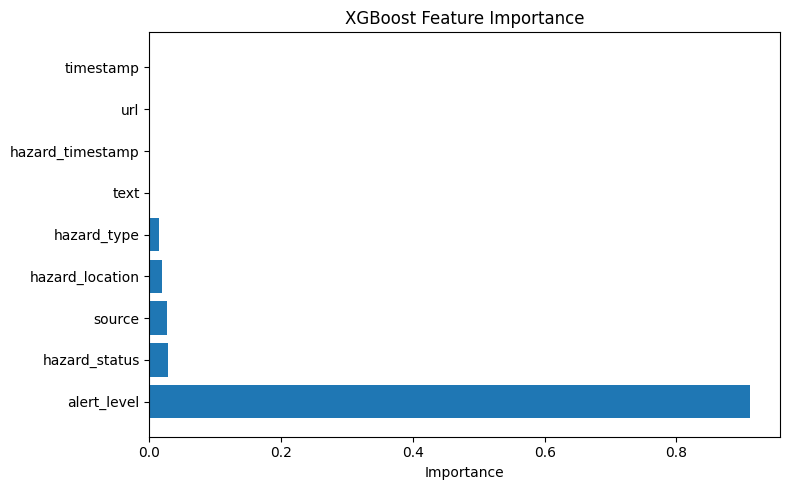

In [53]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['feature'], importance_df['importance'])
ax.set_xlabel('Importance')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig(REPORT_DIR / f'feature_importance_{RUN_ID}.png', dpi=150)
plt.show()

## 10. Save Artefacts & Report

In [58]:
# ── Save model ────────────────────────────────────────────────────────────
prefix      = config['output']['checkpoint_prefix']
model_path  = CHECKPOINT_DIR / f'{prefix}_{RUN_ID}.joblib'
joblib.dump({'model': model, 'label_encoders': label_encoders, 'target_le': target_le}, model_path)
print(f'Model saved: {model_path}')

# ── Save metrics report ───────────────────────────────────────────────────
report = {
    'run_id':      RUN_ID,
    'config':      config,
    'features':    ALL_FEATURES,
    'metrics':     results_df.to_dict(orient='records'),
    'robustness':  robustness_df.to_dict(orient='records'),
    'importance':  importance_df.to_dict(orient='records'),
}

report_path = REPORT_DIR / f'optimised_core_xgb_report_{RUN_ID}.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

# Also save a flat CSV for easy comparison across runs
results_df['run_id'] = RUN_ID
csv_path = REPORT_DIR / 'all_runs_metrics.csv'
header = not csv_path.exists()
results_df.to_csv(csv_path, mode='a', index=False, header=header)

print(f'Report saved: {report_path}')
print(f'Metrics appended to: {csv_path}')

Model saved: ..\checkpoints\core_xgb_20260515_222517.joblib
Report saved: ..\reports\optimised_core_xgb_report_20260515_222517.json
Metrics appended to: ..\reports\all_runs_metrics.csv


## 11. Print Output Paths

In [59]:
print("Report saved to:", report_path.resolve())
print("Model saved to:", model_path.resolve())
print("CSV saved to:", csv_path.resolve())
print("Report dir exists:", REPORT_DIR.exists())

Report saved to: C:\Users\sjbra\Documents\Phoenix\ai-ml\models\core-models\xgb\reports\optimised_core_xgb_report_20260515_222517.json
Model saved to: C:\Users\sjbra\Documents\Phoenix\ai-ml\models\core-models\xgb\checkpoints\core_xgb_20260515_222517.joblib
CSV saved to: C:\Users\sjbra\Documents\Phoenix\ai-ml\models\core-models\xgb\reports\all_runs_metrics.csv
Report dir exists: True
